# Lab Exercise 10
## Learning the XOR Boolean Function Using a Multi-Layer Perceptron (MLP)

**Description:** In this lab, we implement a Multi-Layer Perceptron (MLP) to learn the XOR Boolean function — a classic non-linearly separable problem. We build the MLP using two approaches: **Keras (TensorFlow high-level API)** and **TensorFlow low-level API**. We also study the effect of hyperparameters such as learning rate, activation function, number of neurons, and number of epochs on model performance.

---
## Aim

1. Understand how to implement neural networks using deep learning libraries such as **Keras** and **TensorFlow**.
2. Solve the non-linear XOR problem using a Multi-Layer Perceptron (MLP) and study the effect of hyperparameters such as learning rate, activation function, number of neurons, and number of epochs on model performance.

---
## Theory

### What is XOR?
XOR (Exclusive OR) is a logical operation that outputs **1** only when the inputs are **different**, and **0** when they are the same.

| Input 1 | Input 2 | XOR Output |
|---------|---------|------------|
| 0       | 0       | 0          |
| 0       | 1       | 1          |
| 1       | 0       | 1          |
| 1       | 1       | 0          |

### Why is XOR a Non-Linear Problem?
XOR cannot be separated by a single straight line (linear boundary). A single-layer perceptron (which draws a linear decision boundary) **cannot** learn XOR. This was famously demonstrated by Minsky & Papert (1969). A non-linear model such as an MLP with a hidden layer is required.

### What is an MLP (Multi-Layer Perceptron)?
An MLP is a feedforward neural network consisting of:
- **Input Layer:** Receives the input features (for XOR: 2 inputs).
- **Hidden Layer(s):** One or more layers of neurons that apply non-linear transformations, enabling the network to learn complex patterns.
- **Output Layer:** Produces the final prediction (for XOR: 1 output neuron with sigmoid activation for binary classification).

### Activation Functions
- **ReLU (Rectified Linear Unit):** `f(x) = max(0, x)`. Fast, avoids vanishing gradient for positive values. Output range: [0, ∞).
- **Tanh (Hyperbolic Tangent):** `f(x) = tanh(x)`. Output range: (-1, 1). Zero-centered, often works well for hidden layers.
- **Sigmoid:** `f(x) = 1 / (1 + e^(-x))`. Output range: (0, 1). Used in the output layer for binary classification to produce a probability.

### Binary Cross-Entropy Loss
The standard loss function for binary classification: `L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]`. It penalizes confident wrong predictions heavily.

### Learning Rate
Controls the step size during gradient descent. Too high → overshooting; too low → slow convergence.

### Epoch
One complete pass through the entire training dataset during training.

### Adam Optimizer
An adaptive learning rate optimizer that combines Momentum and RMSProp. It maintains per-parameter learning rates and is widely used due to its efficiency and robustness.

---
## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

ModuleNotFoundError: No module named 'tensorflow'

---
## 2. Create the XOR Dataset

In [ ]:
# XOR input and output
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print("XOR Dataset:")
print(f"{'Input 1':<10}{'Input 2':<10}{'Output':<10}")
print("-" * 30)
for i in range(len(X)):
    print(f"{int(X[i][0]):<10}{int(X[i][1]):<10}{int(y[i][0]):<10}")

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

XOR Dataset:
Input 1   Input 2   Output    
------------------------------
0         0         0         
0         1         1         
1         0         1         
1         1         0         

X shape: (4, 2)
y shape: (4, 1)


---
## 3. Implementation 1 — Keras (TensorFlow High-Level API)

We build an MLP using `tf.keras.Sequential` with:
- 1 hidden layer (4 neurons, Tanh activation)
- 1 output neuron (Sigmoid activation)
- Binary cross-entropy loss & Adam optimizer

In [ ]:
# === Keras Hyperparameters (configurable) ===
KERAS_HIDDEN_NEURONS = 4
KERAS_ACTIVATION = 'tanh'
KERAS_LEARNING_RATE = 0.1
KERAS_EPOCHS = 1000

# Reset seeds
np.random.seed(42)
tf.random.set_seed(42)

# Build the model
keras_model = keras.Sequential([
    layers.Dense(KERAS_HIDDEN_NEURONS, activation=KERAS_ACTIVATION, input_shape=(2,), name='hidden_layer'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
], name='XOR_MLP_Keras')

# Compile with Adam optimizer and binary cross-entropy loss
optimizer = keras.optimizers.Adam(learning_rate=KERAS_LEARNING_RATE)
keras_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
keras_model.summary()

Model: "XOR_MLP_Keras"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 hidden_layer (Dense)        (None, 4)                 12        


 output_layer (Dense)        (None, 1)                 5         


Total params: 17 (68.00 Byte)


Trainable params: 17 (68.00 Byte)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [ ]:
# Train the Keras model
print(f"Training Keras MLP for {KERAS_EPOCHS} epochs...")
print(f"Config: hidden_neurons={KERAS_HIDDEN_NEURONS}, activation={KERAS_ACTIVATION}, lr={KERAS_LEARNING_RATE}\n")

keras_history = keras_model.fit(X, y, epochs=KERAS_EPOCHS, verbose=0)

# Training results
keras_final_loss = keras_history.history['loss'][-1]
keras_final_acc = keras_history.history['accuracy'][-1]

print(f"Training complete!")
print(f"Final Loss:     {keras_final_loss:.6f}")
print(f"Final Accuracy: {keras_final_acc * 100:.2f}%")

Training Keras MLP for 1000 epochs...
Config: hidden_neurons=4, activation=tanh, lr=0.1



Training complete!
Final Loss:     0.000207
Final Accuracy: 100.00%


In [ ]:
# Keras Predictions
keras_predictions = keras_model.predict(X, verbose=0)
keras_binary = (keras_predictions > 0.5).astype(int)

print("\nKeras Predictions:")
print(f"{'Input 1':<10}{'Input 2':<10}{'Expected':<10}{'Prob':<12}{'Predicted':<10}")
print("-" * 52)
for i in range(len(X)):
    print(f"{int(X[i][0]):<10}{int(X[i][1]):<10}{int(y[i][0]):<10}{keras_predictions[i][0]:<12.4f}{keras_binary[i][0]:<10}")

# Calculate accuracy manually
keras_accuracy = np.mean(keras_binary == y) * 100
print(f"\nAccuracy: {keras_accuracy:.2f}%")


Keras Predictions:
Input 1   Input 2   Expected  Prob        Predicted 
----------------------------------------------------
0         0         0         0.0000      0         
0         1         1         0.9996      1         
1         0         1         0.9999      1         
1         1         0         0.0003      0         

Accuracy: 100.00%


---
## 4. Keras Training Curve

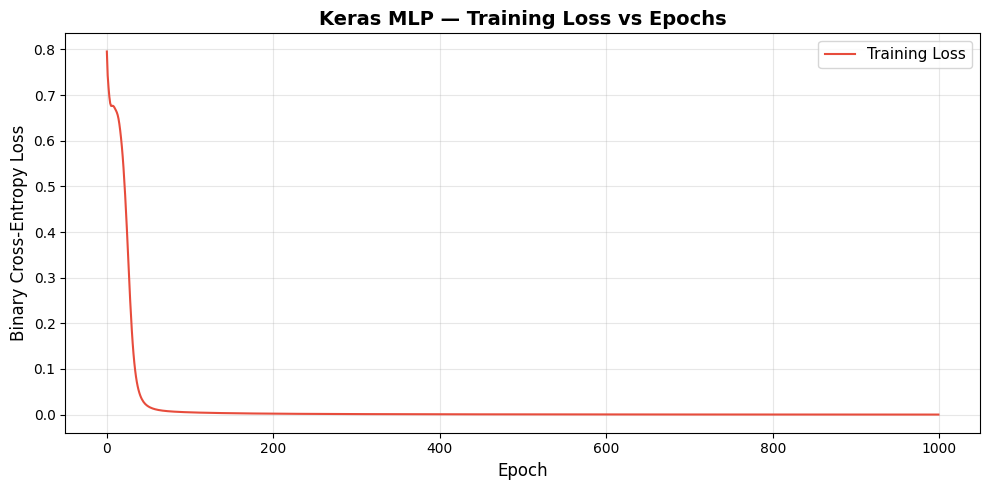

In [ ]:
# Plot Keras training loss
plt.figure(figsize=(10, 5))
plt.plot(keras_history.history['loss'], color='#e74c3c', linewidth=1.5, label='Training Loss')
plt.title('Keras MLP — Training Loss vs Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Implementation 2 — TensorFlow Low-Level API

We implement the same MLP **without** using `model.fit()` or `Sequential()`. Instead, we:
- Define weights and biases manually as `tf.Variable`
- Write the forward pass explicitly
- Use `tf.GradientTape` for backpropagation
- Create a manual training loop

In [ ]:
# === TensorFlow Low-Level Hyperparameters (configurable) ===
TF_HIDDEN_NEURONS = 4
TF_ACTIVATION = 'tanh'        # 'tanh' or 'relu'
TF_LEARNING_RATE = 0.1
TF_EPOCHS = 1000

# Reset seeds
np.random.seed(42)
tf.random.set_seed(42)

# Convert data to TensorFlow tensors
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Initialize weights and biases manually
# Hidden layer: 2 inputs -> TF_HIDDEN_NEURONS neurons
W1 = tf.Variable(tf.random.normal([2, TF_HIDDEN_NEURONS], stddev=0.5), name='W1')
b1 = tf.Variable(tf.zeros([TF_HIDDEN_NEURONS]), name='b1')

# Output layer: TF_HIDDEN_NEURONS -> 1 neuron
W2 = tf.Variable(tf.random.normal([TF_HIDDEN_NEURONS, 1], stddev=0.5), name='W2')
b2 = tf.Variable(tf.zeros([1]), name='b2')

print(f"W1 shape: {W1.shape}  (input -> hidden)")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}  (hidden -> output)")
print(f"b2 shape: {b2.shape}")

W1 shape: (2, 4)  (input -> hidden)
b1 shape: (4,)
W2 shape: (4, 1)  (hidden -> output)
b2 shape: (1,)


In [ ]:
# Define the activation function
def apply_activation(x, name):
    """Apply activation function by name."""
    if name == 'tanh':
        return tf.nn.tanh(x)
    elif name == 'relu':
        return tf.nn.relu(x)
    else:
        raise ValueError(f"Unknown activation: {name}")

# Forward pass function
def forward_pass(X, W1, b1, W2, b2, activation_name):
    """Explicit forward pass through the MLP."""
    # Hidden layer
    hidden = apply_activation(tf.matmul(X, W1) + b1, activation_name)
    # Output layer with sigmoid
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

# Binary cross-entropy loss function
def compute_loss(y_true, y_pred):
    """Compute binary cross-entropy loss."""
    # Clip predictions to avoid log(0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    loss = -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
    return loss

print("Forward pass and loss functions defined.")

Forward pass and loss functions defined.


In [ ]:
# === Manual Training Loop ===
optimizer_tf = tf.optimizers.Adam(learning_rate=TF_LEARNING_RATE)
trainable_vars = [W1, b1, W2, b2]

tf_loss_history = []

print(f"Training TF Low-Level MLP for {TF_EPOCHS} epochs...")
print(f"Config: hidden_neurons={TF_HIDDEN_NEURONS}, activation={TF_ACTIVATION}, lr={TF_LEARNING_RATE}\n")

for epoch in range(TF_EPOCHS):
    with tf.GradientTape() as tape:
        # Forward pass
        predictions = forward_pass(X_tf, W1, b1, W2, b2, TF_ACTIVATION)
        # Compute loss
        loss = compute_loss(y_tf, predictions)
    
    # Compute gradients
    gradients = tape.gradient(loss, trainable_vars)
    # Update weights
    optimizer_tf.apply_gradients(zip(gradients, trainable_vars))
    
    tf_loss_history.append(loss.numpy())
    
    # Print progress every 200 epochs
    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:>4d}/{TF_EPOCHS} — Loss: {loss.numpy():.6f}")

tf_final_loss = tf_loss_history[-1]
print(f"\nTraining complete!")
print(f"Final Loss: {tf_final_loss:.6f}")

Training TF Low-Level MLP for 1000 epochs...
Config: hidden_neurons=4, activation=tanh, lr=0.1



Epoch    1/1000 — Loss: 0.688937

Epoch  200/1000 — Loss: 0.001648


Epoch  400/1000 — Loss: 0.000619


Epoch  600/1000 — Loss: 0.000336


Epoch  800/1000 — Loss: 0.000215


Epoch 1000/1000 — Loss: 0.000150

Training complete!
Final Loss: 0.000150


In [ ]:
# TensorFlow Low-Level Predictions
tf_predictions = forward_pass(X_tf, W1, b1, W2, b2, TF_ACTIVATION).numpy()
tf_binary = (tf_predictions > 0.5).astype(int)

print("TensorFlow Low-Level Predictions:")
print(f"{'Input 1':<10}{'Input 2':<10}{'Expected':<10}{'Prob':<12}{'Predicted':<10}")
print("-" * 52)
for i in range(len(X)):
    print(f"{int(X[i][0]):<10}{int(X[i][1]):<10}{int(y[i][0]):<10}{tf_predictions[i][0]:<12.4f}{tf_binary[i][0]:<10}")

# Calculate accuracy
tf_accuracy = np.mean(tf_binary == y) * 100
print(f"\nAccuracy: {tf_accuracy:.2f}%")

TensorFlow Low-Level Predictions:
Input 1   Input 2   Expected  Prob        Predicted 
----------------------------------------------------
0         0         0         0.0000      0         
0         1         1         0.9997      1         
1         0         1         0.9999      1         
1         1         0         0.0003      0         

Accuracy: 100.00%


---
## 6. TensorFlow Low-Level Training Curve

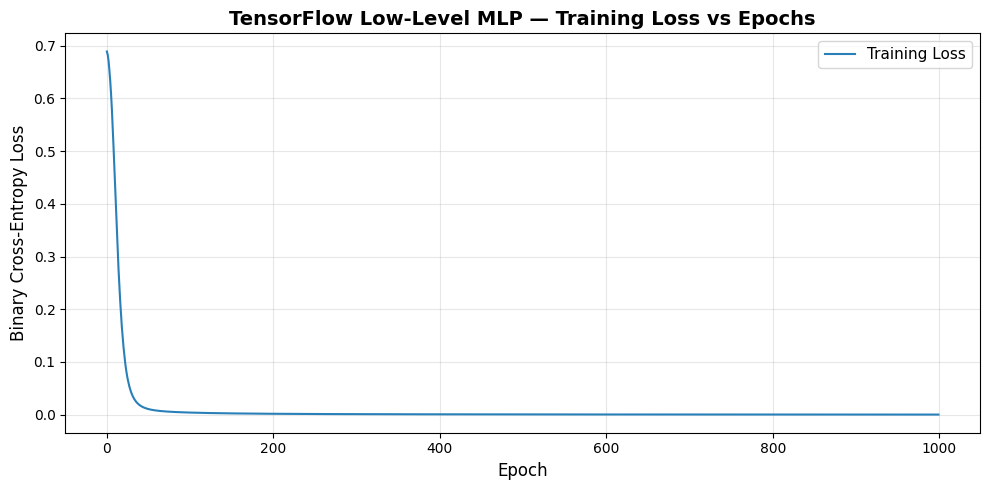

In [ ]:
# Plot TensorFlow Low-Level training loss
plt.figure(figsize=(10, 5))
plt.plot(tf_loss_history, color='#2980b9', linewidth=1.5, label='Training Loss')
plt.title('TensorFlow Low-Level MLP — Training Loss vs Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Hyperparameter Experiments

We study the effect of different hyperparameters on XOR learning using the Keras implementation.

### A. Effect of Learning Rate

Experiment A: Effect of Learning Rate
Fixed: hidden_neurons=4, activation=tanh, epochs=1000
Learning Rate  Final Loss     Accuracy       
---------------------------------------------


0.001          0.220033       100.00         %


0.01           0.002544       100.00         %


0.1            0.000238       100.00         %


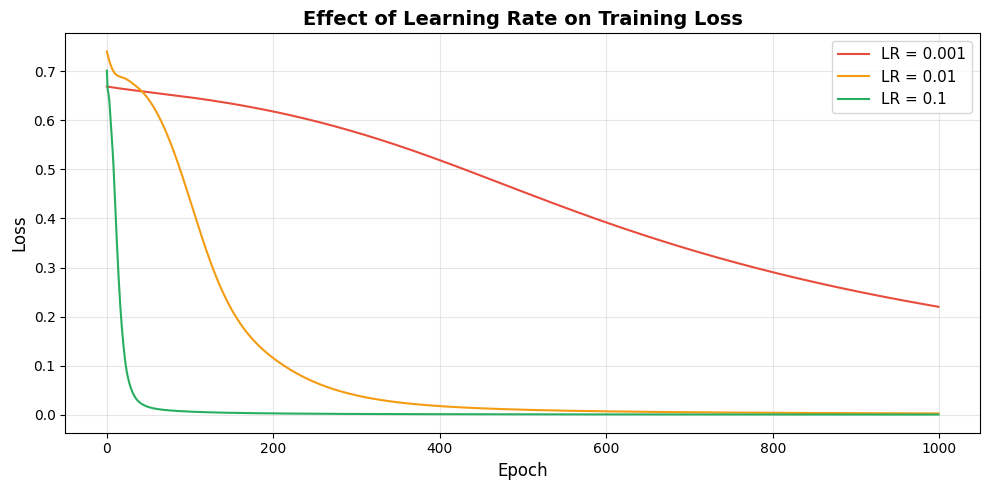

In [ ]:
# Experiment A: Learning Rate
learning_rates = [0.001, 0.01, 0.1]

print("=" * 55)
print("Experiment A: Effect of Learning Rate")
print(f"Fixed: hidden_neurons=4, activation=tanh, epochs=1000")
print("=" * 55)
print(f"{'Learning Rate':<15}{'Final Loss':<15}{'Accuracy':<15}")
print("-" * 45)

lr_losses = {}

for lr in learning_rates:
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = keras.Sequential([
        layers.Dense(4, activation='tanh', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X, y, epochs=1000, verbose=0)
    
    preds = (model.predict(X, verbose=0) > 0.5).astype(int)
    acc = np.mean(preds == y) * 100
    final_loss = history.history['loss'][-1]
    lr_losses[lr] = history.history['loss']
    
    print(f"{lr:<15}{final_loss:<15.6f}{acc:<15.2f}%")

# Plot comparison
plt.figure(figsize=(10, 5))
colors = ['#e74c3c', '#f39c12', '#27ae60']
for (lr, losses), color in zip(lr_losses.items(), colors):
    plt.plot(losses, label=f'LR = {lr}', linewidth=1.5, color=color)
plt.title('Effect of Learning Rate on Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### B. Effect of Number of Hidden Neurons

Experiment B: Effect of Number of Hidden Neurons
Fixed: learning_rate=0.1, activation=tanh, epochs=1000
Neurons        Final Loss     Accuracy       
---------------------------------------------


2              0.000408       100.00         %


4              0.000245       100.00         %


8              0.000048       100.00         %


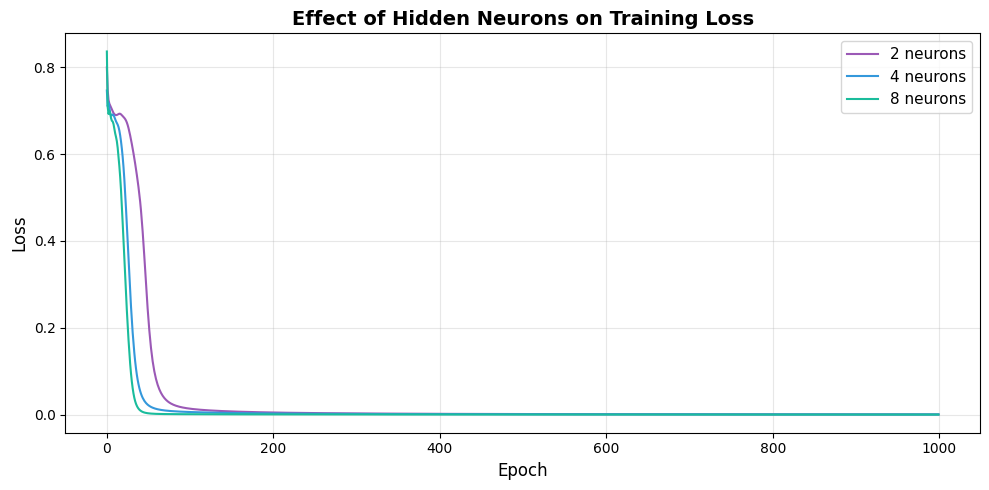

In [ ]:
# Experiment B: Number of Hidden Neurons
neuron_counts = [2, 4, 8]

print("=" * 55)
print("Experiment B: Effect of Number of Hidden Neurons")
print(f"Fixed: learning_rate=0.1, activation=tanh, epochs=1000")
print("=" * 55)
print(f"{'Neurons':<15}{'Final Loss':<15}{'Accuracy':<15}")
print("-" * 45)

neuron_losses = {}

for n in neuron_counts:
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = keras.Sequential([
        layers.Dense(n, activation='tanh', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
                  loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X, y, epochs=1000, verbose=0)
    
    preds = (model.predict(X, verbose=0) > 0.5).astype(int)
    acc = np.mean(preds == y) * 100
    final_loss = history.history['loss'][-1]
    neuron_losses[n] = history.history['loss']
    
    print(f"{n:<15}{final_loss:<15.6f}{acc:<15.2f}%")

# Plot comparison
plt.figure(figsize=(10, 5))
colors = ['#9b59b6', '#3498db', '#1abc9c']
for (n, losses), color in zip(neuron_losses.items(), colors):
    plt.plot(losses, label=f'{n} neurons', linewidth=1.5, color=color)
plt.title('Effect of Hidden Neurons on Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### C. Effect of Number of Epochs

In [ ]:
# Experiment C: Number of Epochs
epoch_counts = [100, 500, 1000]

print("=" * 55)
print("Experiment C: Effect of Number of Epochs")
print(f"Fixed: hidden_neurons=4, activation=tanh, lr=0.1")
print("=" * 55)
print(f"{'Epochs':<15}{'Final Loss':<15}{'Accuracy':<15}")
print("-" * 45)

for ep in epoch_counts:
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = keras.Sequential([
        layers.Dense(4, activation='tanh', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
                  loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X, y, epochs=ep, verbose=0)
    
    preds = (model.predict(X, verbose=0) > 0.5).astype(int)
    acc = np.mean(preds == y) * 100
    final_loss = history.history['loss'][-1]
    
    print(f"{ep:<15}{final_loss:<15.6f}{acc:<15.2f}%")

Experiment C: Effect of Number of Epochs
Fixed: hidden_neurons=4, activation=tanh, lr=0.1
Epochs         Final Loss     Accuracy       
---------------------------------------------


100            0.005820       100.00         %


500            0.000672       100.00         %


1000           0.000234       100.00         %


### D. Effect of Activation Function

Experiment D: Effect of Activation Function
Fixed: hidden_neurons=4, lr=0.1, epochs=1000
Activation     Final Loss     Accuracy       
---------------------------------------------


relu           0.346582       75.00          %


tanh           0.000214       100.00         %


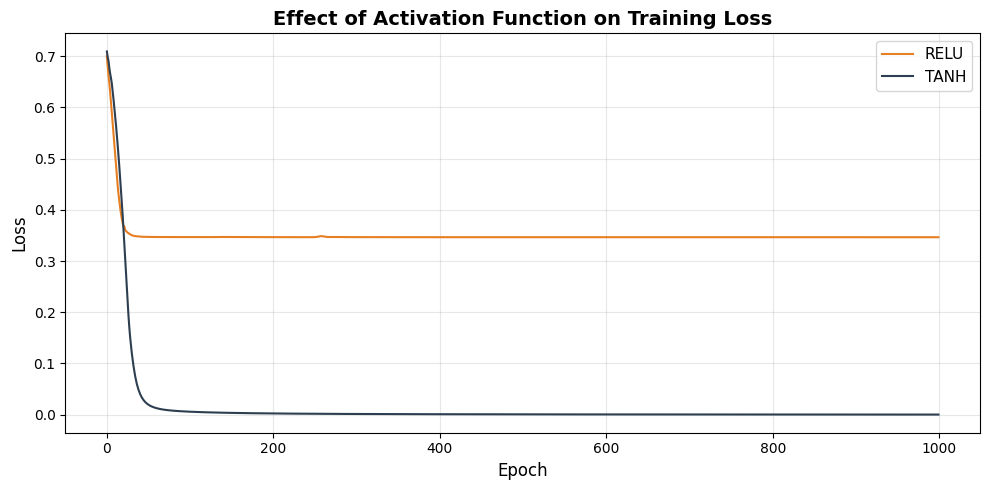

In [ ]:
# Experiment D: Activation Function
activations = ['relu', 'tanh']

print("=" * 55)
print("Experiment D: Effect of Activation Function")
print(f"Fixed: hidden_neurons=4, lr=0.1, epochs=1000")
print("=" * 55)
print(f"{'Activation':<15}{'Final Loss':<15}{'Accuracy':<15}")
print("-" * 45)

act_losses = {}

for act in activations:
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = keras.Sequential([
        layers.Dense(4, activation=act, input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
                  loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X, y, epochs=1000, verbose=0)
    
    preds = (model.predict(X, verbose=0) > 0.5).astype(int)
    acc = np.mean(preds == y) * 100
    final_loss = history.history['loss'][-1]
    act_losses[act] = history.history['loss']
    
    print(f"{act:<15}{final_loss:<15.6f}{acc:<15.2f}%")

# Plot comparison
plt.figure(figsize=(10, 5))
colors = ['#e67e22', '#2c3e50']
for (act, losses), color in zip(act_losses.items(), colors):
    plt.plot(losses, label=f'{act.upper()}', linewidth=1.5, color=color)
plt.title('Effect of Activation Function on Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Comparison Table

Comparing the Keras and TensorFlow Low-Level implementations.

In [ ]:
# Comparison Table
print("=" * 90)
print("COMPARISON TABLE: Keras vs TensorFlow Low-Level API")
print("=" * 90)
print(f"{'Implementation':<20}{'Neurons':<10}{'Activation':<12}{'Optimizer':<10}{'LR':<8}{'Epochs':<8}{'Loss':<12}{'Accuracy':<10}")
print("-" * 90)
print(f"{'Keras':<20}{KERAS_HIDDEN_NEURONS:<10}{KERAS_ACTIVATION:<12}{'Adam':<10}{KERAS_LEARNING_RATE:<8}{KERAS_EPOCHS:<8}{keras_final_loss:<12.6f}{keras_accuracy:<10.2f}%")
print(f"{'TF Low-Level':<20}{TF_HIDDEN_NEURONS:<10}{TF_ACTIVATION:<12}{'Adam':<10}{TF_LEARNING_RATE:<8}{TF_EPOCHS:<8}{tf_final_loss:<12.6f}{tf_accuracy:<10.2f}%")
print("=" * 90)

COMPARISON TABLE: Keras vs TensorFlow Low-Level API
Implementation      Neurons   Activation  Optimizer LR      Epochs  Loss        Accuracy  
------------------------------------------------------------------------------------------
Keras               4         tanh        Adam      0.1     1000    0.000207    100.00    %
TF Low-Level        4         tanh        Adam      0.1     1000    0.000150    100.00    %


---
## 9. Decision Boundary Visualization (Optional)

We plot the 2D decision boundary learned by the best-performing Keras model.

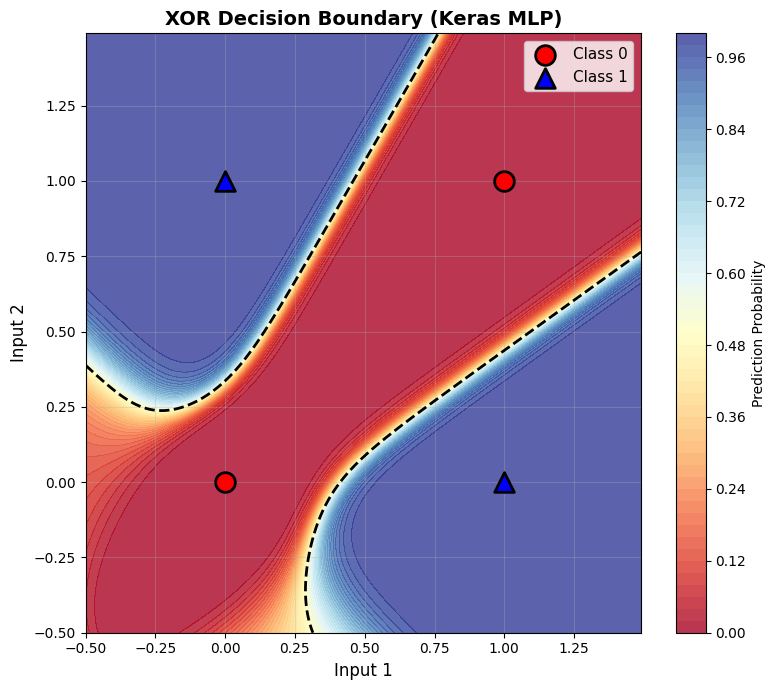

Decision boundary plotted successfully.


In [ ]:
# Decision Boundary Plot
try:
    # Create a fine mesh grid
    h = 0.01  # step size
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid_input = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    
    # Predict on grid
    Z = keras_model.predict(grid_input, verbose=0)
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(8, 7))
    plt.contourf(xx, yy, Z, levels=50, cmap='RdYlBu', alpha=0.8)
    plt.colorbar(label='Prediction Probability')
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    # Plot XOR data points
    for i in range(len(X)):
        if y[i][0] == 0:
            plt.scatter(X[i][0], X[i][1], c='red', s=200, edgecolors='black',
                       linewidths=2, zorder=5, marker='o', label='Class 0' if i == 0 else '')
        else:
            plt.scatter(X[i][0], X[i][1], c='blue', s=200, edgecolors='black',
                       linewidths=2, zorder=5, marker='^', label='Class 1' if i == 1 else '')
    
    plt.title('XOR Decision Boundary (Keras MLP)', fontsize=14, fontweight='bold')
    plt.xlabel('Input 1', fontsize=12)
    plt.ylabel('Input 2', fontsize=12)
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Decision boundary plotted successfully.")

except Exception as e:
    print(f"Could not plot decision boundary: {e}")

---
## 10. Final Result

In [ ]:
# Final Result — XOR Truth Table with Predictions
print("=" * 70)
print("                         XOR TRUTH TABLE")
print("=" * 70)
print(f"{'Input 1':<10}{'Input 2':<10}{'Expected':<12}{'Predicted':<12}{'Probability':<12}")
print("-" * 56)

# Use the Keras model predictions for final result
final_preds = keras_model.predict(X, verbose=0)
final_binary = (final_preds > 0.5).astype(int)

for i in range(len(X)):
    print(f"{int(X[i][0]):<10}{int(X[i][1]):<10}{int(y[i][0]):<12}{final_binary[i][0]:<12}{final_preds[i][0]:<12.4f}")

print("-" * 56)
final_acc = np.mean(final_binary == y) * 100
print(f"\nFinal Accuracy: {final_acc:.2f}%")
print("=" * 70)

                         XOR TRUTH TABLE
Input 1   Input 2   Expected    Predicted   Probability 
--------------------------------------------------------
0         0         0           0           0.0000      
0         1         1           1           0.9996      
1         0         1           1           0.9999      
1         1         0           0           0.0003      
--------------------------------------------------------

Final Accuracy: 100.00%


---
## Conclusion

1. **XOR cannot be solved by a single linear neuron.** The XOR function is non-linearly separable, meaning no single straight line can divide the classes. A single-layer perceptron fails to learn XOR.

2. **An MLP with a hidden layer can learn XOR.** By introducing a hidden layer with multiple neurons, the network gains the capacity to create non-linear decision boundaries and correctly classify all four XOR inputs.

3. **Non-linear activation functions** (such as Tanh and ReLU) allow the network to learn the non-linear XOR relationship. Without non-linear activations, even multiple layers would behave like a single linear transformation.

4. **Binary cross-entropy** is the appropriate loss function for binary classification tasks like XOR, as it measures the divergence between predicted probabilities and actual labels.

5. **Hyperparameters significantly affect convergence and performance:**
   - **Learning rate:** Too low leads to slow convergence; too high can cause instability.
   - **Number of neurons:** More neurons provide greater capacity; at least 2 hidden neurons are needed for XOR.
   - **Activation function:** Tanh and ReLU both work, with Tanh often converging faster for XOR due to its zero-centered nature.
   - **Number of epochs:** Sufficient training iterations are necessary for the model to converge.

6. **Both Keras and TensorFlow low-level API** can successfully learn the XOR function. Keras provides a simpler, high-level interface, while TensorFlow low-level API offers full control over the training process.

---
## Viva Questions & Answers

**Q1. What is XOR?**
> XOR (Exclusive OR) is a logical operation that outputs 1 when the inputs are different and 0 when they are the same.

**Q2. Why is XOR non-linear?**
> XOR is non-linear because its outputs cannot be separated by a single straight line in 2D space. No linear decision boundary can correctly classify all four XOR input combinations.

**Q3. What is an MLP?**
> A Multi-Layer Perceptron (MLP) is a feedforward neural network with at least one hidden layer between the input and output layers. It can learn non-linear functions.

**Q4. Why is a hidden layer required for XOR?**
> A hidden layer with non-linear activation allows the network to transform the input into a higher-dimensional space where the XOR classes become linearly separable.

**Q5. Why use sigmoid in the output layer?**
> Sigmoid squashes the output to the range (0, 1), making it interpretable as a probability for binary classification. A threshold of 0.5 converts it to a class label.

**Q6. Why use binary cross-entropy?**
> Binary cross-entropy is the standard loss function for binary classification. It measures how different the predicted probability distribution is from the actual label distribution.

**Q7. What is an epoch?**
> An epoch is one complete forward and backward pass through the entire training dataset.

**Q8. What is learning rate?**
> Learning rate is a hyperparameter that controls the step size during gradient descent. It determines how much the model weights are updated in each iteration.

**Q9. What is the difference between ReLU and Tanh?**
> ReLU outputs max(0, x) with range [0, ∞) and is computationally efficient. Tanh outputs values in (-1, 1) and is zero-centered, which can help with convergence. ReLU may suffer from the "dying neuron" problem, while Tanh can have vanishing gradients.

**Q10. What is the difference between Keras and TensorFlow low-level API?**
> Keras is a high-level API that provides simple abstractions like `Sequential()` and `model.fit()` for quick model building. TensorFlow low-level API requires manually defining weights, writing the forward pass, computing gradients with `GradientTape`, and implementing the training loop, giving full control over every step.